<a href="https://colab.research.google.com/github/roboy88/Global-Aid-to-Ukraine-/blob/main/Global_Aid_to_Ukraine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving Ukraine_support_tracker.csv to Ukraine_support_tracker.csv


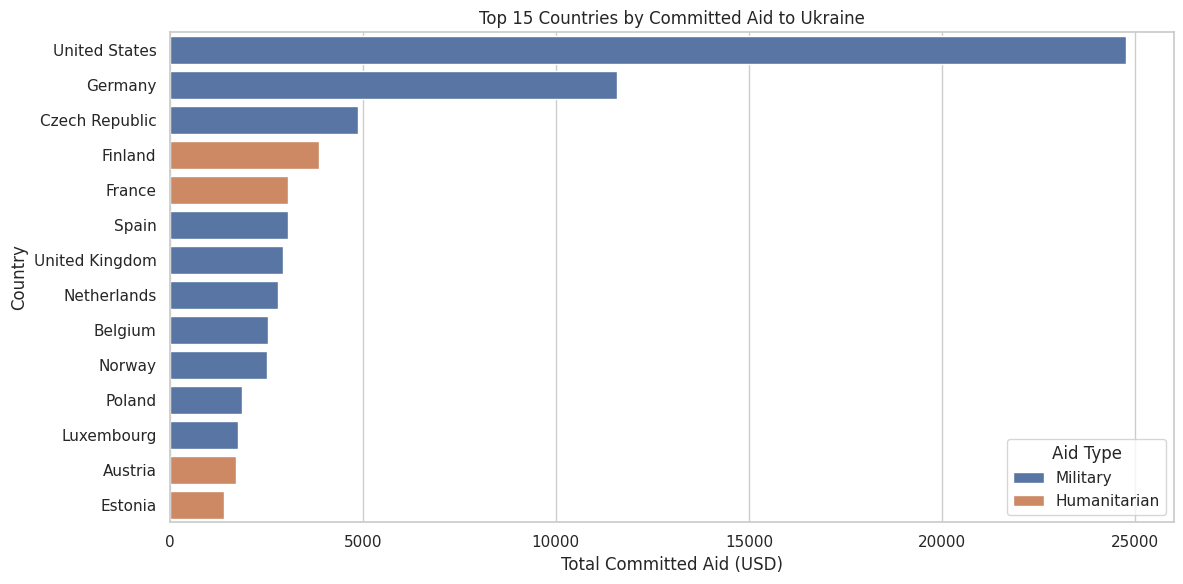

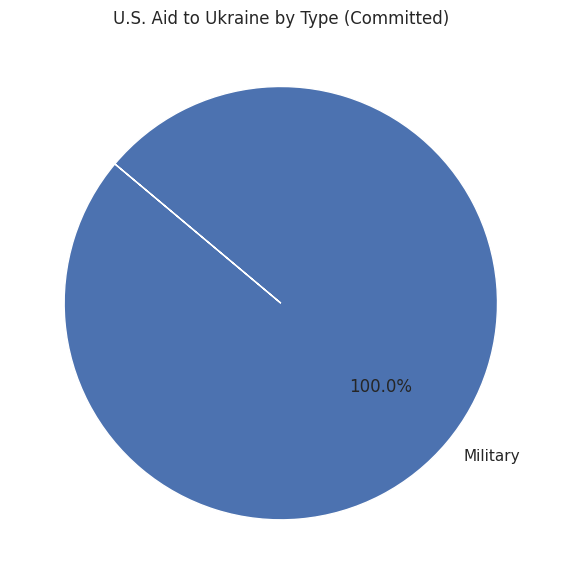

In [1]:
# === TITLE: Global Aid to Ukraine — Who Gave What and How Much? ===

# === STEP 1: IMPORT LIBRARIES ===
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

# === STEP 2: UPLOAD FILE ===
uploaded = files.upload()  # Upload 'Ukraine_support_tracker.csv' when prompted

# === STEP 3: LOAD DATA ===
# Use proper delimiter (semicolon) and skip problematic lines
support_df = pd.read_csv("Ukraine_support_tracker.csv", delimiter=';', engine='python', on_bad_lines='skip')

# === STEP 4: CLEAN COLUMN NAMES ===
support_df.columns = support_df.columns.str.strip()

# === STEP 5: CREATE IN-MEMORY SQL DATABASE ===
conn = sqlite3.connect(":memory:")
support_df.to_sql("ukraine_support", conn, index=False, if_exists="replace")

# === STEP 6: RUN SQL QUERY ===
query = """
SELECT
    Countries,
    "Type of Aid General" AS aid_type,
    SUM(CAST("Value Committed (own estimate, in USD)" AS FLOAT)) AS total_committed_usd,
    SUM(CAST("Value Delivered (own estimate, in USD)" AS FLOAT)) AS total_delivered_usd
FROM ukraine_support
WHERE "Value Committed (own estimate, in USD)" IS NOT NULL
GROUP BY Countries, aid_type
ORDER BY total_committed_usd DESC
LIMIT 15
"""
aid_summary = pd.read_sql_query(query, conn)

# === STEP 7: BAR CHART: TOP 15 DONORS BY AID TYPE ===
sns.set(style="whitegrid")
plt.figure(figsize=(12, 6))
sns.barplot(
    data=aid_summary,
    x="total_committed_usd",
    y="Countries",
    hue="aid_type",
    dodge=False
)
plt.title("Top 15 Countries by Committed Aid to Ukraine")
plt.xlabel("Total Committed Aid (USD)")
plt.ylabel("Country")
plt.legend(title="Aid Type")
plt.tight_layout()
plt.show()

# === STEP 8: PIE CHART: U.S. AID BREAKDOWN ===
us_aid = aid_summary[aid_summary["Countries"] == "United States"]
if not us_aid.empty:
    plt.figure(figsize=(6, 6))
    plt.pie(
        us_aid["total_committed_usd"],
        labels=us_aid["aid_type"],
        autopct="%1.1f%%",
        startangle=140
    )
    plt.title("U.S. Aid to Ukraine by Type (Committed)")
    plt.tight_layout()
    plt.show()
else:
    print("No data found for United States.")
